In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(
    '../Dataset/loan_approval_data.xlsx',
    engine='openpyxl'
)

In [5]:
gen=df['Gender'].mode()[0]

df['Gender'].fillna(value=gen, inplace=True)


mar=df['Married'].mode()[0]
mar
df['Married'].fillna(value=mar, inplace=True)



dep=df['Dependency'].mode()[0]
dep
df['Dependency'].fillna(value=dep, inplace=True)

edu=df['Education'].mode()[0]
edu
df['Education'].fillna(value=edu, inplace=True)



emp=df['Self_Employed'].mode()[0]
emp
df['Self_Employed'].fillna(value=emp, inplace=True)

num_cols = [
    'ApplicantIncome',
    'LoanAmount'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_14420\585880595.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(value=gen, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_14420\585880595.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [6]:
bin=[
    0,3126.000000,5055.000000,8736.250000
, float('inf')
]
label=[
    'Low', 'Medium','High','Very High'
]

df['Income_category']= pd.cut(df['ApplicantIncome'],
                              bins=bin,
                              labels=label)

df["Large_loan"]=np.where(
    df['LoanAmount']>170

    , 1,0
)



In [7]:
x= df.drop('Loan_Status', axis=1)

y = df['Loan_Status'].map({
    'Y':1,
    'N':0
})
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    # stratify=y
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

num_features = [ 'ApplicantIncome', 'LoanAmount', 'Large_loan' ] 

num_transformer=StandardScaler() 
cat_transformer=OneHotEncoder( handle_unknown='ignore',
drop='first' ) 


ordinal_transformer = OrdinalEncoder( )

binary_features = [ 'Gender', 'Married', 'Education', 'Self_Employed', ] 

ordinal_features = [ 'Dependency', 'Income_category' ]

binary_features = [ 'Gender', 'Married', 'Education', 'Self_Employed', ] 

ordinal_features = [ 'Dependency', 'Income_category' ]

processor=ColumnTransformer(transformers=[
    ('num', num_transformer,num_features),
    ('cat',cat_transformer,binary_features),
    ('ord',ordinal_transformer, ordinal_features)


])

x_train_transformed=processor.fit_transform(x_train)
x_test_transformed=processor.transform(x_test)

df.drop('Loan_ID', axis=1, inplace=True)


processor.get_feature_names_out()

array(['num__ApplicantIncome', 'num__LoanAmount', 'num__Large_loan',
       'cat__Gender_Male', 'cat__Married_Yes',
       'cat__Education_Not Graduate', 'cat__Self_Employed_Yes',
       'ord__Dependency', 'ord__Income_category'], dtype=object)

In [18]:
class LogisticReg:
    def __init__(self,lr=0.01,epoch=1000):
        self.lr=lr
        self.epoch=epoch
        self.weights=None
        self.bias=None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self,x,y):
        n_samples, n_features = x.shape        
        self.weights=np.zeros(n_features)
        self.bias = 0
        for epochs in range(self.epoch):
            z = np.dot(x, self.weights) + self.bias
            y_hat = self.sigmoid(z)

            dw=(1/n_samples)*np.dot(x.T,(y_hat-y))
            db=(1/n_samples)*np.sum(y_hat-y)
            self.weights = self.weights - self.lr * dw

            self.bias = self.bias - self.lr * db
    def predict_proba(self, X):
         z = np.dot(X, self.weights) + self.bias
         return self.sigmoid(z)
    def predict(self, X):

        probabilities = self.predict_proba(X)

        predictions = np.where(probabilities >= 0.5, 1, 0)

        return predictions



In [19]:
model = LogisticReg()

model.fit(x_train_transformed, y_train.to_numpy())

In [20]:
y_prob = model.predict_proba(x_test_transformed)

print(y_prob[:10])

[0.4666099  0.45821181 0.42502219 0.35015015 0.43773011 0.54393767
 0.44144018 0.51320776 0.81991234 0.36847549]


In [21]:
y_pred = model.predict(x_test_transformed)

print(y_pred[:10])

[0 0 0 0 0 1 0 1 1 0]


In [22]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print("Accuracy :", acc)

Accuracy : 0.7


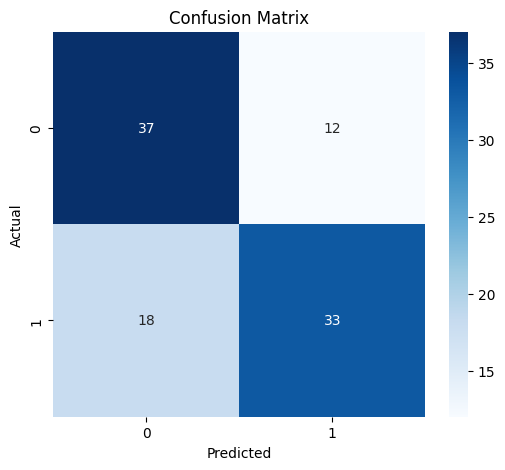

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

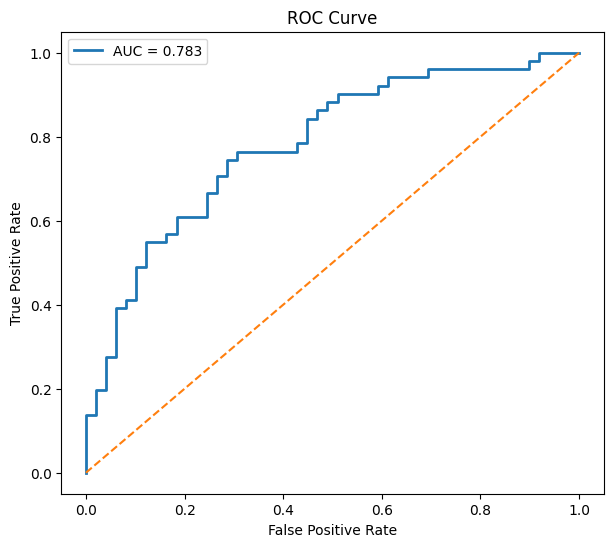

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

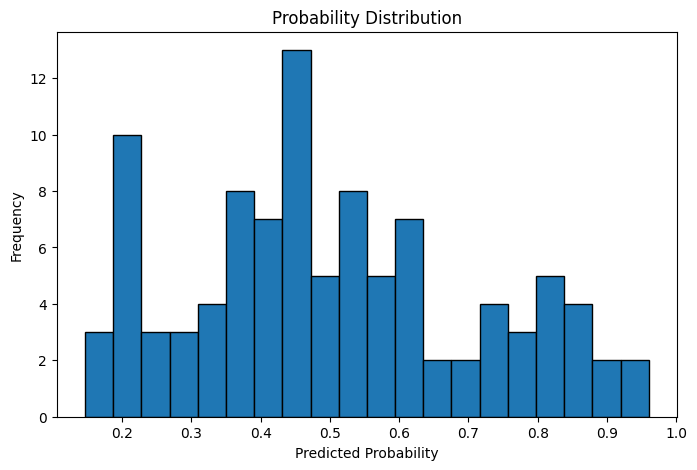

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=20,
    edgecolor='black'
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution")

plt.show()

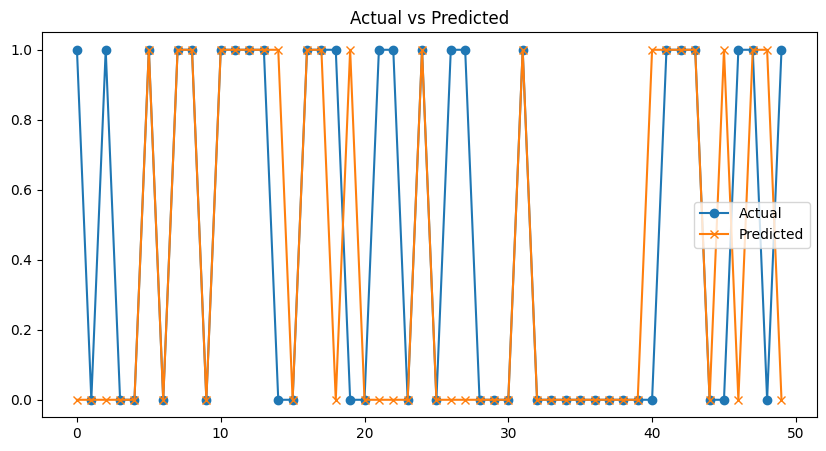

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.to_numpy()[:50],
    label="Actual",
    marker='o'
)

plt.plot(
    y_pred[:50],
    label="Predicted",
    marker='x'
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7


In [ ]:
# y_prob = model.predict_proba(x_test)[:,1]

ValueError: shapes (100,10) and (9,) not aligned: 10 (dim 1) != 9 (dim 0)

In [28]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC :", auc)

AUC : 0.7827130852340936


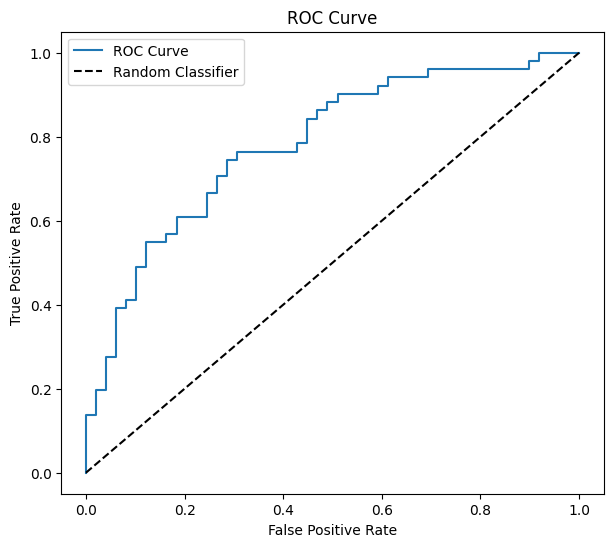

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'k--',label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
thresholds

array([       inf, 0.96019088, 0.85244057, 0.84252476, 0.81865097,
       0.80804939, 0.77767423, 0.75659788, 0.64637498, 0.63847442,
       0.63226227, 0.6280479 , 0.61299552, 0.5970002 , 0.57692295,
       0.56305167, 0.55319859, 0.55091869, 0.54393767, 0.51658175,
       0.49457169, 0.48849292, 0.47914778, 0.47042316, 0.46657617,
       0.46387536, 0.46243776, 0.44031176, 0.43813945, 0.43773011,
       0.42482961, 0.41799436, 0.41521255, 0.41226036, 0.39254772,
       0.38993701, 0.3793903 , 0.35272145, 0.35057918, 0.35015015,
       0.33759293, 0.3047469 , 0.30226605, 0.19839446, 0.19823185,
       0.19453331, 0.19411001, 0.14668026])

In [32]:
n_samples, n_features = x_test_transformed.shape

In [33]:
n_samples

100

In [34]:
n_features


9